In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [2]:
data = pd.read_csv('data/full_merged_with_aqi.csv')
data.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,precipcover,windspeed,sealevelpressure,tempmax_humidity,tempmin_humidity,temp_humidity,temp_range,heat_index,conditions,AQI
0,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
1,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
2,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
3,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
4,31.47687,76.09127,367.0,0.79,0.78,2021-04-12,653.0,N20,VIIRS,h,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226


In [3]:
cols_to_drop = ['scan', 'track', 'acq_time', 
                'satellite', 'instrument', 'confidence', 
                'version', 'type', 'latitude', 'longitude',
                'feelslike', 'feelslikemax', 'feelslikemin',
                'precipprob']

data.drop(columns=cols_to_drop, inplace=True)
data.head()

,brightness,acq_date,bright_t31,frp,daynight,dist_to_delhi,Latitude,Longitude,Telemetry Hourly Wind Speed (Km/Hr),tempmax,...,precipcover,windspeed,sealevelpressure,tempmax_humidity,tempmin_humidity,temp_humidity,temp_range,heat_index,conditions,AQI
0,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
1,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
2,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
3,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226
4,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,0.0,18.4,1011.6,1083.6,585.2,834.4,17.8,115.201975,Clear,226


In [4]:
data['weighted_distance'] = data['dist_to_delhi'] / data['windspeed']

In [5]:
ml_df = data.copy()
data.columns

Index(['brightness', 'acq_date', 'bright_t31', 'frp', 'daynight',
       'dist_to_delhi', 'Latitude', 'Longitude',
       'Telemetry Hourly Wind Speed (Km/Hr)', 'tempmax', 'tempmin', 'temp',
       'humidity', 'precip', 'precipcover', 'windspeed', 'sealevelpressure',
       'tempmax_humidity', 'tempmin_humidity', 'temp_humidity', 'temp_range',
       'heat_index', 'conditions', 'AQI', 'weighted_distance'],
      dtype='object')

In [6]:
catagorical_cols = ['daynight', 'conditions']

list(ml_df['daynight'].unique()), list(ml_df['conditions'].unique())

(['D', 'N'],
 ['Clear',
  'Partially cloudy',
  'Rain, Partially cloudy',
  'Rain, Overcast',
  'Rain'])

In [7]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

labels = ml_df["daynight"].values.reshape(-1, 1)

ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(labels)

ml_df['daynight_encoded'] = encoded[:, 0]

labels = ml_df["conditions"].values.reshape(-1, 1)
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(labels)

ml_df['conditions_encoded'] = encoded[:, 0]

In [8]:
ml_df['acq_date'] = pd.to_datetime(ml_df['acq_date'])
ml_df['day'] = ml_df['acq_date'].dt.day
ml_df['month'] = ml_df['acq_date'].dt.month
ml_df['year'] = ml_df['acq_date'].dt.year
ml_df['day_of_week'] = ml_df['acq_date'].dt.dayofweek

ml_df.head()

,brightness,acq_date,bright_t31,frp,daynight,dist_to_delhi,Latitude,Longitude,Telemetry Hourly Wind Speed (Km/Hr),tempmax,...,heat_index,conditions,AQI,weighted_distance,daynight_encoded,conditions_encoded,day,month,year,day_of_week
0,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,115.201975,Clear,226,18.262406,1.0,1.0,12,4,2021,0
1,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,115.201975,Clear,226,18.262406,1.0,1.0,12,4,2021,0
2,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,115.201975,Clear,226,18.262406,1.0,1.0,12,4,2021,0
3,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,115.201975,Clear,226,18.262406,1.0,1.0,12,4,2021,0
4,367.0,2021-04-12,299.59,52.2,D,336.028277,30.140833,74.207778,40.4,38.7,...,115.201975,Clear,226,18.262406,1.0,1.0,12,4,2021,0


In [9]:
ml_df.columns

Index(['brightness', 'acq_date', 'bright_t31', 'frp', 'daynight',
       'dist_to_delhi', 'Latitude', 'Longitude',
       'Telemetry Hourly Wind Speed (Km/Hr)', 'tempmax', 'tempmin', 'temp',
       'humidity', 'precip', 'precipcover', 'windspeed', 'sealevelpressure',
       'tempmax_humidity', 'tempmin_humidity', 'temp_humidity', 'temp_range',
       'heat_index', 'conditions', 'AQI', 'weighted_distance',
       'daynight_encoded', 'conditions_encoded', 'day', 'month', 'year',
       'day_of_week'],
      dtype='object')

In [10]:
feature_cols = [
    'brightness',  
    'bright_t31', 
    'frp', 
    'dist_to_delhi', 
    'Latitude', 
    'Longitude',
	'Telemetry Hourly Wind Speed (Km/Hr)', 
	'tempmax',
	'tempmin', 
	'temp',
	'humidity', 
	'precip', 
	'precipcover', 
	'windspeed', 
	'sealevelpressure',
	'tempmax_humidity', 
	'tempmin_humidity', 
	'temp_humidity', 
	'temp_range',
	'heat_index', 
    'weighted_distance',
	'daynight_encoded', 
	'conditions_encoded',
    'day', 
    'month', 
    'year',
    'day_of_week'
]

In [11]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    random_state=42
)

X = ml_df[feature_cols]
y = ml_df['AQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)	
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"HistGradientBoostingRegressor Model Performance:")
print(f"R² Score: {r2}")		
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

HistGradientBoostingRegressor Model Performance:
R² Score: 0.9956325099108476
Mean Squared Error: 35.88337442887805
Mean Absolute Error: 2.942808707830886


In [83]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

# print(importance_df)
importance_df.to_csv('feature_importance_hist_gradient_boosting.csv', index=False)

In [ ]:
# def make_plots(y_test, y_pred, title_suffix=''):
# 	import matplotlib.pyplot as plt

# 	plt.figure()
# 	plt.scatter(y_test, y_pred, alpha=0.1, s=5)
# 	plt.plot([y_test.min(), y_test.max()],
# 			 [y_test.min(), y_test.max()])
# 	plt.xlabel("Actual AQI")
# 	plt.ylabel("Predicted AQI")
# 	plt.title(f"Actual vs Predicted AQI {title_suffix}")
# 	plt.savefig(rf'results\actual_vs_predicted_aqi-{title_suffix.replace(" ","_")}.png')
# 	plt.show()
# 	plt.close()
	

# 	residuals = y_test - y_pred

# 	plt.figure()
# 	plt.scatter(y_pred, residuals, alpha=0.1, s=5)
# 	plt.axhline(0)
# 	plt.xlabel("Predicted AQI")
# 	plt.ylabel("Residual (Actual − Predicted)")
# 	plt.title(f"Residuals vs Predicted AQI {title_suffix}")
# 	plt.savefig(rf'results\residuals_vs_predicted_aqi-{title_suffix.replace(" ","_")}.png')
# 	plt.show()
# 	plt.close()
	

# 	plt.figure()
# 	plt.hist(residuals, bins=100)
# 	plt.xlabel("Residual")
# 	plt.title(f"Residual Distribution {title_suffix}")
# 	plt.savefig(rf'results\residual_distribution-{title_suffix.replace(" ","_")}.png')
# 	plt.show()
# 	plt.close()
	

In [46]:
def make_plots(y_test, y_pred, title_suffix=''):
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
    import os

    os.makedirs("results", exist_ok=True)

    # metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    residuals = y_test - y_pred

    # create single figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --- Actual vs Predicted ---
    axes[0].scatter(y_test, y_pred, alpha=0.5, s=5)
    axes[0].plot([y_test.min(), y_test.max()],
                 [y_test.min(), y_test.max()])
    axes[0].set_xlabel("Actual AQI")
    axes[0].set_ylabel("Predicted AQI")
    axes[0].set_title("Actual vs Predicted")

    # --- Residuals vs Predicted ---
    axes[1].scatter(y_pred, residuals, alpha=0.5, s=5)
    axes[1].axhline(0)
    axes[1].set_xlabel("Predicted AQI")
    axes[1].set_ylabel("Residual")
    axes[1].set_title("Residuals vs Predicted")

    # --- Residual Distribution ---
    axes[2].hist(residuals, bins=100)
    axes[2].set_xlabel("Residual")
    axes[2].set_title("Residual Distribution")

    # metrics text box
    metrics_text = (
        f"R²   : {r2:.4f}\n"
        f"MSE : {mse:.2f}\n"
        f"RMSE : {rmse:.2f}\n"
        f"MAE  : {mae:.2f}"
    )

    fig.text(
        0.5, -0.05, metrics_text,
        ha="center", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
    )

    fig.suptitle(f"AQI Model Performance {title_suffix}", fontsize=14)
    fig.tight_layout()

    fig.savefig(
        rf"results\model_diagnostics-{title_suffix.replace(' ','_')}.png",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


In [12]:
ml_df.to_csv(r'data\ml_df_processed.csv', index=False)

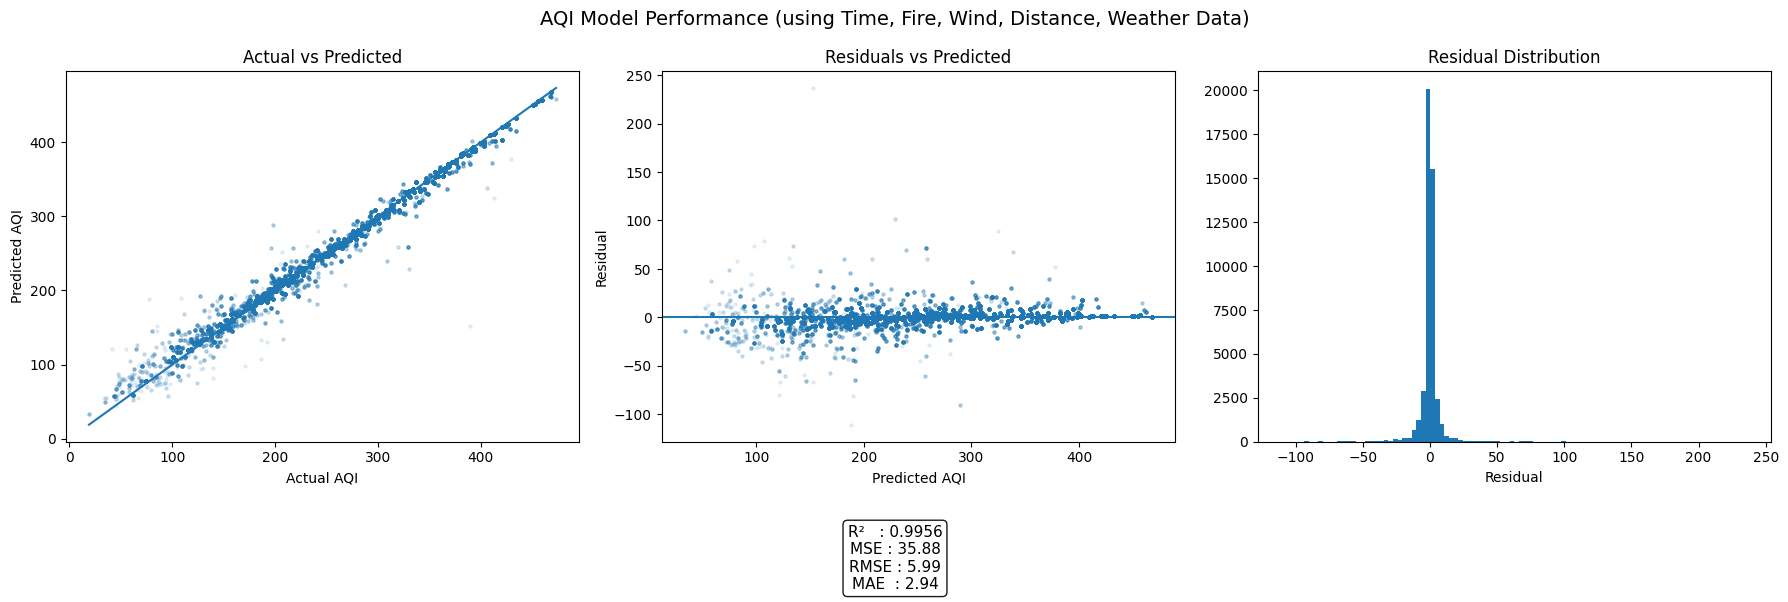

In [78]:
make_plots(y_test, y_pred, title_suffix='(using Time, Fire, Wind, Distance, Weather Data)')

In [63]:
X = ml_df[feature_cols]
y = ml_df['AQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Linear Regression Model Performance:")
print(f"R² Score: {r2}")
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

Linear Regression Model Performance:
R² Score: 0.2323088329843611
Mean Squared Error: 6307.363961783025
Mean Absolute Error: 63.29718040538821


In [16]:
newdf = ml_df.copy()
newdf.columns

Index(['brightness', 'acq_date', 'bright_t31', 'frp', 'daynight',
       'dist_to_delhi', 'Latitude', 'Longitude',
       'Telemetry Hourly Wind Speed (Km/Hr)', 'tempmax', 'tempmin', 'temp',
       'humidity', 'precip', 'precipcover', 'windspeed', 'sealevelpressure',
       'tempmax_humidity', 'tempmin_humidity', 'temp_humidity', 'temp_range',
       'heat_index', 'conditions', 'AQI', 'weighted_distance',
       'daynight_encoded', 'conditions_encoded', 'day', 'month', 'year',
       'day_of_week'],
      dtype='object')

In [17]:
newdf.drop(columns=['day', 'day_of_week'], inplace=True)

In [18]:
# --- Ensure date column is datetime ---
newdf['acq_date'] = pd.to_datetime(newdf['acq_date'])

# --- Create weighted FRP column ---
newdf['weighted_frp'] = newdf['brightness'] * newdf['frp']

# --- Columns definitions ---
avg_cols = [
    'Latitude',
    'Longitude',
    'dist_to_delhi',
    'Telemetry Hourly Wind Speed (Km/Hr)',
    'windspeed'
]

sum_cols = [
    'brightness',
    'frp'
]

# --- Groupby object ---
grouped = newdf.groupby('acq_date')

# --- Aggregations ---
avg_df = grouped[avg_cols].mean()
sum_df = grouped[sum_cols].sum()

# --- Total records per day ---
count_df = grouped.size().rename('records_per_day')

# --- Weighted FRP daily sum ---
weighted_frp_sum = grouped['weighted_frp'].sum()

# --- Calculate avg weighted FRP ---
avg_weighted_frp = (weighted_frp_sum / count_df).rename('avg_wei_frp')

# --- Remaining columns → take first record of each day ---
remaining_cols = [col for col in newdf.columns if col not in (
    avg_cols + sum_cols + ['weighted_frp', 'acq_date']
)]

first_df = grouped[remaining_cols].first()

# --- Merge everything ---
final_daily_df = pd.concat([
    avg_df,
    sum_df,
    avg_weighted_frp,
    first_df
], axis=1).reset_index()

# --- Output ---
final_daily_df.head()


,acq_date,Latitude,Longitude,dist_to_delhi,Telemetry Hourly Wind Speed (Km/Hr),windspeed,brightness,frp,avg_wei_frp,bright_t31,...,temp_humidity,temp_range,heat_index,conditions,AQI,weighted_distance,daynight_encoded,conditions_encoded,month,year
0,2021-04-12,30.140833,74.207778,336.028277,40.4,18.4,78538.00,11170.80,19157.400,299.59,...,834.40,17.8,115.201975,Clear,226,18.262406,1.0,1.0,4,2021
1,2021-04-13,30.140833,74.207778,204.154206,28.4,18.5,62997.05,1096.86,2109.183,308.77,...,869.25,18.4,115.146444,Clear,279,11.035362,1.0,1.0,4,2021
2,2021-04-14,30.140833,74.207778,76.602201,32.0,18.4,33764.00,1193.24,4759.990,314.75,...,787.50,16.8,103.744022,Partially cloudy,214,4.163163,1.0,0.0,4,2021
3,2021-04-15,30.140833,74.207778,70.627184,32.0,19.8,33100.65,223.74,755.631,308.14,...,748.07,16.1,100.941229,Partially cloudy,235,3.567029,1.0,0.0,4,2021
4,2021-04-16,30.140833,74.207778,116.073974,28.4,37.1,9688.00,85.40,1055.300,310.36,...,1137.60,18.6,146.415782,"Rain, Partially cloudy",232,3.128679,1.0,0.0,4,2021


In [24]:
len(final_daily_df)

for item in  final_daily_df.columns:
	print(item)

acq_date
Latitude
Longitude
dist_to_delhi
Telemetry Hourly Wind Speed (Km/Hr)
windspeed
brightness
frp
avg_wei_frp
bright_t31
daynight
tempmax
tempmin
temp
humidity
precip
precipcover
sealevelpressure
tempmax_humidity
tempmin_humidity
temp_humidity
temp_range
heat_index
conditions
AQI
weighted_distance
daynight_encoded
conditions_encoded
month
year


In [60]:
feature_cols = [
# 'acq_date',
# 'Latitude',
# 'Longitude',
'dist_to_delhi',
'Telemetry Hourly Wind Speed (Km/Hr)',
'windspeed',
'brightness',
'frp',
'avg_wei_frp',
'bright_t31',
# 'daynight',
'tempmax',
'tempmin',
'temp',
'humidity',
'precip',
'precipcover',
'sealevelpressure',
'tempmax_humidity',
'tempmin_humidity',
'temp_humidity',
'temp_range',
'heat_index',
# 'conditions',
# 'AQI',
'weighted_distance',
'daynight_encoded',
'conditions_encoded',
'month',
'year'
]

In [73]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.051,
    random_state=42
)

X = final_daily_df[feature_cols]
y = final_daily_df['AQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)	
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"HistGradientBoostingRegressor Model Performance:")
print(f"R² Score: {r2}")		
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

HistGradientBoostingRegressor Model Performance:
R² Score: 0.6283975679689506
Mean Squared Error: 3723.157481188886
Mean Absolute Error: 45.350964233133304


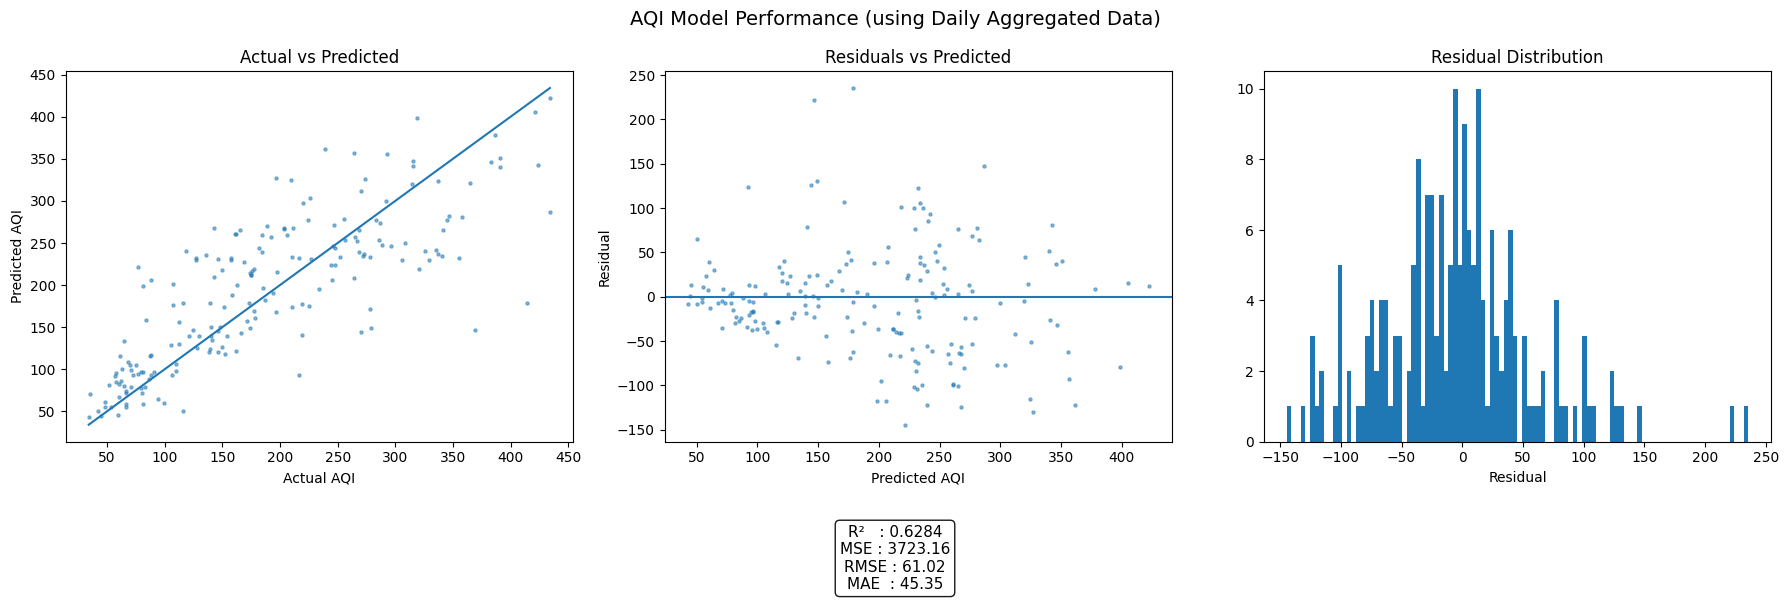

In [74]:
make_plots(y_test, y_pred, title_suffix='(using Daily Aggregated Data)')

In [44]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

# print(importance_df)
importance_df.to_csv('feature_importance_hist_gradient_boosting.csv', index=False)

In [45]:
importance_df.head()

,feature,importance
15,tempmin_humidity,0.448158
22,month,0.190288
10,humidity,0.058077
13,sealevelpressure,0.033755
2,windspeed,0.026838
